# Base Line Experiment

In [ ]:
import pandas as pd
from transformers import pipeline

# List Model

MODEL_REGISTRY = {
    "cahya": {
        "type": "hf",
        "model": "cahya/bert-base-indonesian-NER",
        "tokenizer": "cahya/bert-base-indonesian-NER"
    },


    "xlmr": {
        "type": "hf",
        "model": "Davlan/xlm-roberta-base-ner-hrl",
        "tokenizer": "Davlan/xlm-roberta-base-ner-hrl"
    },
    "flair": {
        "type": "flair",
        "model": "flair/ner-indonesian-large"
    }
}

# Load Model
loaded_models = {}

for name, cfg in MODEL_REGISTRY.items():
    if cfg["type"] == "hf":
        print(f"🔄 Load Hugging Face model: {name}")
        loaded_models[name] = pipeline(
            "ner",
            model=cfg["model"],
            tokenizer=cfg["tokenizer"],
            aggregation_strategy="simple"
        )

print("Semua model berhasil dimuat!")



In [ ]:
def extract_entities(text, model_pipeline):
    hasil = model_pipeline(str(text))
    entities = {"PER": [], "ORG": [], "LOC": []}
    for ent in hasil:
        label = ent.get("entity_group") or ent.get("label")
        word = ent.get("word") or ent.get("text")
        label = label.split("-")[-1]
        if label in entities:
            entities[label].append(word)
    return entities


df = pd.read_csv("/content/2025_09_gt.csv")


for model_name, model_pipeline in loaded_models.items():
    print(f"Running NER dengan model: {model_name}")
    df[f"{model_name}_entities"] = df["summary"].apply(lambda x: extract_entities(x, model_pipeline))

    df[f"{model_name}_PER"] = df[f"{model_name}_entities"].apply(lambda x: x["PER"])
    df[f"{model_name}_ORG"] = df[f"{model_name}_entities"].apply(lambda x: x["ORG"])
    df[f"{model_name}_LOC"] = df[f"{model_name}_entities"].apply(lambda x: x["LOC"])

print("Selesai! Hasil disimpan")


In [ ]:
# Format Output

columns_to_drop = [f"{name}_entities" for name in loaded_models.keys()]
df = df.drop(columns=columns_to_drop)


model_prefixes = ['gt', 'old'] + list(loaded_models.keys())
entity_types = ['PER', 'LOC', 'ORG']

new_column_order = ['hashtitle', 'summary']
for entity in entity_types:
    for prefix in model_prefixes:
        column_name = f"{prefix}_{entity}"
        if column_name in df.columns:
            new_column_order.append(column_name)

remaining_columns = [col for col in df.columns if col not in new_column_order]
final_order = new_column_order + remaining_columns

df = df[final_order]

print("Urutan kolom berhasil diatur!")
print("Urutan kolom baru:", df.columns.tolist())

In [ ]:
df

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Baseline Evaluation

In [ ]:
import pandas as pd
import ast
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

def normalize_list(x):
    """Normalisasi input menjadi list of lowercase string."""
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
    if not isinstance(x, list):
        return []
    return [str(i).lower().strip() for i in x if i]

def evaluate_ner(df, model_prefix):
    """
    Fungsi untuk mengevaluasi hasil NER dengan metrik precision, recall, dan f1-score.
    """
    results = {}

    column_mapping = [
        ("PER", "gt_PER", f"{model_prefix}_PER"),
        ("ORG", "gt_ORG", f"{model_prefix}_ORG"),
        ("LOC", "gt_LOC", f"{model_prefix}_LOC"),
    ]

    for label, col_gt, col_pred in column_mapping:
        y_true_all, y_pred_all = [], []

        for _, row in df.iterrows():
            y_true = set(normalize_list(row[col_gt]))
            y_pred = set(normalize_list(row[col_pred]))

            all_entities = y_true.union(y_pred)
            if not all_entities:
                continue

            for ent in all_entities:
                y_true_all.append(1 if ent in y_true else 0)
                y_pred_all.append(1 if ent in y_pred else 0)

        p, r, f, _ = precision_recall_fscore_support(
            y_true_all, y_pred_all, average="binary", zero_division=0
        )
        results[label] = {"precision": p, "recall": r, "f1": f}

    labels_for_avg = ["PER", "ORG", "LOC"]
    p_macro = np.mean([results[l]["precision"] for l in labels_for_avg])
    r_macro = np.mean([results[l]["recall"] for l in labels_for_avg])
    f_macro = np.mean([results[l]["f1"] for l in labels_for_avg])
    results["Macro Avg"] = {"precision": p_macro, "recall": r_macro, "f1": f_macro}

    return pd.DataFrame(results).T

# Evaluasi untuk model lama (menggunakan kolom 'old_PER', 'old_ORG', 'old_LOC')
old_results = evaluate_ner(df, "old")

# Evaluasi untuk model 'cahya'
cahya_results = evaluate_ner(df, "cahya")

# Evaluasi untuk model 'xlmr'
xlmr_results = evaluate_ner(df, "xlmr")

print("\nEvaluasi Old Model:\n", old_results, "\n")
print("Evaluasi Model Cahya:\n", cahya_results, "\n")
print("Evaluasi Model XLM-R:\n", xlmr_results)


Evaluasi Old Model:
            precision    recall        f1
PER         0.336842  0.581818  0.426667
ORG         0.196078  0.287356  0.233100
LOC         0.452514  0.413265  0.432000
Macro Avg   0.328478  0.427480  0.363922 

Evaluasi Model Cahya:
            precision    recall        f1
PER         0.438596  0.681818  0.533808
ORG         0.116541  0.178161  0.140909
LOC         0.111111  0.051020  0.069930
Macro Avg   0.222083  0.303667  0.248216 

Evaluasi Model XLM-R:
            precision    recall        f1
PER         0.478788  0.718182  0.574545
ORG         0.185484  0.396552  0.252747
LOC         0.348958  0.683673  0.462069
Macro Avg   0.337743  0.599469  0.429787


In [ ]:
all_results = {
    "old": old_results,
    "cahya": cahya_results,
    "xlmr": xlmr_results
}

f1_summary = pd.DataFrame({
    model_name: results['f1']
    for model_name, results in all_results.items()
})

f1_summary = f1_summary.reindex(['Macro Avg', 'PER', 'LOC', 'ORG'])
print(f1_summary)


 Tabel Ringkasan Perbandingan F1-Score
                old     cahya      xlmr
Macro Avg  0.363922  0.248216  0.429787
PER        0.426667  0.533808  0.574545
LOC        0.432000  0.069930  0.462069
ORG        0.233100  0.140909  0.252747


/tmp/ipython-input-2868914761.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=macro_avg_scores.index, y=macro_avg_scores.values, palette="viridis")


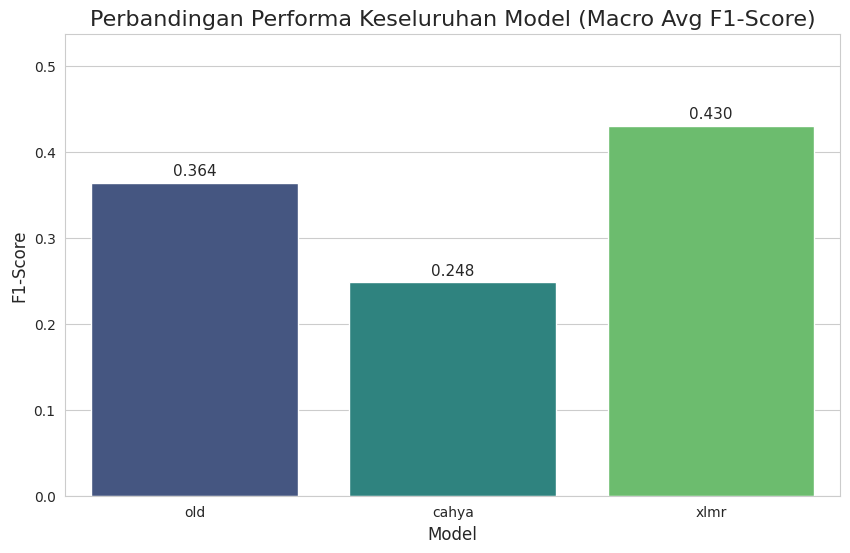

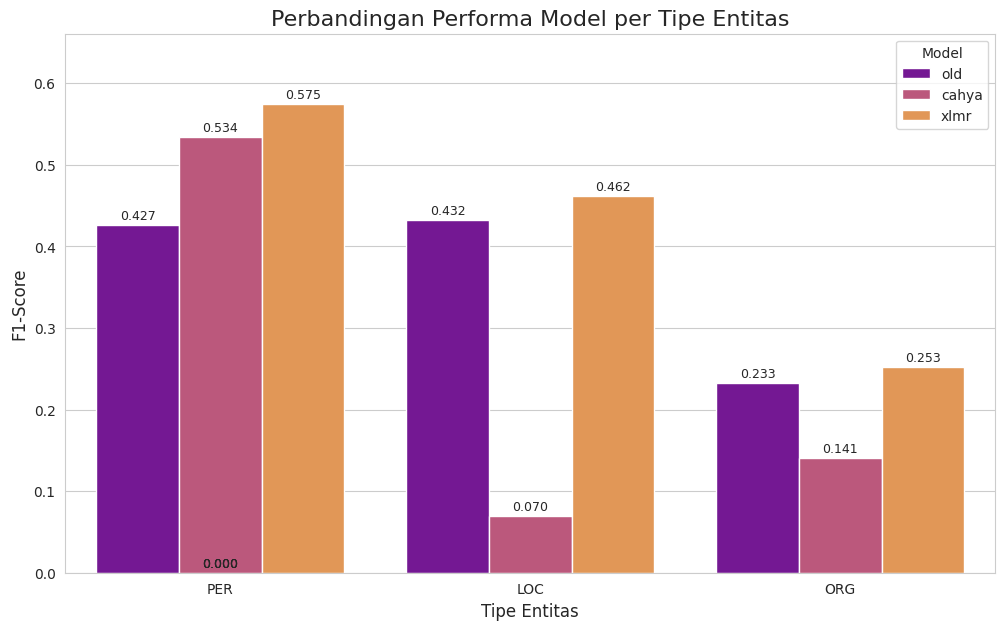

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
macro_avg_scores = f1_summary.loc['Macro Avg']

ax = sns.barplot(x=macro_avg_scores.index, y=macro_avg_scores.values, palette="viridis")

for patch in ax.patches:
    score = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        score + 0.005,
        f'{score:.3f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Perbandingan Performa Keseluruhan Model (Macro Avg F1-Score)', fontsize=16)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, max(macro_avg_scores.values) * 1.25)
plt.show()



f1_summary_melted = f1_summary.drop('Macro Avg').reset_index().rename(columns={'index': 'Entitas'})
f1_summary_melted = f1_summary_melted.melt(id_vars='Entitas', var_name='Model', value_name='F1-Score')

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=f1_summary_melted, x='Entitas', y='F1-Score', hue='Model', palette="plasma")

for patch in ax.patches:
    score = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        score + 0.003,
        f'{score:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Perbandingan Performa Model per Tipe Entitas', fontsize=16)
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Tipe Entitas', fontsize=12)
plt.legend(title='Model')

plt.ylim(0, f1_summary_melted['F1-Score'].max() * 1.15)

plt.show()

# Fine Tune XLMR Iteratif Progressive

In [1]:
# Dependencies

!pip install transformers datasets seqeval evaluate accelerate -q

import json
import numpy as np
from tqdm import tqdm
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    pipeline
)
import evaluate
from google.colab import drive
from transformers import pipeline
import pandas as pd
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.7 MB/s eta 0:00:00


ValueError: mount failed

In [ ]:
#GPU Check

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Current CUDA device:", torch.cuda.current_device())
print("CUDA device name:", torch.cuda.get_device_name(0))


TensorFlow version: 2.19.0
Num GPUs Available:  1
PyTorch version: 2.9.0+cu126
CUDA available: True
Current CUDA device: 0
CUDA device name: Tesla T4


In [ ]:
# SETUP KONFIGURASI

JSON_PATH = "/content/720_clean.json"
# BASE_MODEL = "/content/drive/MyDrive/Kuliah/Magang/SDD/Model/NER/xlmr_finetuned_ner_200"
BASE_MODEL = "/content/drive/MyDrive/magang/Model/NER/xlmr_finetuned_ner_200"
MODEL_SAVE_NAME = "xlmr_finetuned_ner_600"
DATA_LIMIT = 600

In [ ]:
# LOAD DATA JSON (Label Studio Format)

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total data ditemukan: {len(data)}")

if DATA_LIMIT is not None:
    data = data[:DATA_LIMIT]
    print(f"✂️ Data dipotong menjadi: {len(data)} data (limit: {DATA_LIMIT})")
else:
    print(f"📦 Menggunakan semua data: {len(data)} data")

def create_bio_format_labelstudio(data):
    dataset = []
    for item in tqdm(data):
        text = item.get("data", {}).get("summary", "")
        if not text:
            continue

        entities = []
        annotations = item.get("annotations", [])
        if not annotations:
            continue

        results = annotations[0].get("result", [])
        for r in results:
            value = r.get("value", {})
            start = value.get("start")
            end = value.get("end")
            labels = value.get("labels", [])
            if start is None or end is None or not labels:
                continue
            entities.append({
                "start": start,
                "end": end,
                "label": labels[0]
            })

        dataset.append({"text": text, "entities": entities})
    return dataset

bio_data = create_bio_format_labelstudio(data)
print("Contoh data pertama:")
print(bio_data[0])

Total data ditemukan: 990
✂️ Data dipotong menjadi: 600 data (limit: 600)


100%|██████████| 600/600 [00:00<00:00, 22151.84it/s]

Contoh data pertama:
{'text': 'Mapos, Mamuju – Cabor Pickleball adalah salah satu olahraga dengan pertumbuhan paling cepat di dunia saat ini, termasuk di Indonesia, karena mudah dipelajari, menyenangkan, dan dapat dimainkan oleh berbagai usia.  Cabang olahraga pickleball resmi terdaftar keanggotaan di Komite Olahraga Nasional Indonesia (KONI) Kabupaten Mamuju.  Kepastian itu setelah pengurus International Pickleball Federation (IPF) Mamuju mempresentasikan mengenai cabang olahraga tersebut di depan pengurus KONI Mamuju.', 'entities': [{'start': 324, 'end': 330, 'label': 'LOC'}, {'start': 406, 'end': 412, 'label': 'LOC'}, {'start': 123, 'end': 132, 'label': 'LOC'}, {'start': 364, 'end': 412, 'label': 'ORG'}, {'start': 272, 'end': 313, 'label': 'ORG'}]}


In [ ]:
# TOKENISASI DAN ALIGN LABELS

MODEL_NAME = BASE_MODEL
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

label_list = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC"]
label_to_id = {l: i for i, l in enumerate(label_list)}

def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256,
        return_offsets_mapping=True
    )

    all_labels = []
    for i, text in enumerate(examples["text"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        entity_labels = ["O"] * len(word_ids)

        if examples["entities"][i]:
            for ent in examples["entities"][i]:
                start, end, label = ent["start"], ent["end"], ent["label"]
                start_token, end_token = None, None
                for j, offset in enumerate(tokenized_inputs["offset_mapping"][i]):
                    if offset[0] <= start < offset[1]:
                        start_token = j
                    if offset[0] < end <= offset[1]:
                        end_token = j
                if start_token is not None and end_token is not None:
                    entity_labels[start_token] = f"B-{label}"
                    for k in range(start_token + 1, end_token + 1):
                        entity_labels[k] = f"I-{label}"

        all_labels.append([label_to_id.get(l, 0) for l in entity_labels])

    tokenized_inputs["labels"] = all_labels
    tokenized_inputs.pop("offset_mapping")
    return tokenized_inputs

dataset = Dataset.from_list(bio_data)
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

In [ ]:
# SPLIT TRAIN/TEST

split_dataset = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print("Train size:", len(train_dataset))
print("Eval size:", len(eval_dataset))

Train size: 480
Eval size: 120


In [ ]:
# HYPERPARAMETER TUNING WITH OPTUNA

!pip install optuna -q

import optuna
import torch
import gc

# Setup data collator dan metrics
data_collator = DataCollatorForTokenClassification(tokenizer)
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_labels = [[label_list[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

def objective(trial):
    """
    Objective function untuk Optuna optimization
    """
    # hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    per_device_train_batch_size = trial.suggest_categorical("per_device_train_batch_size", [4, 8, 16])
    num_train_epochs = trial.suggest_int("num_train_epochs", 3, 5)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.1)
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.0, 0.2)

    print(f"\n{'='*60}")
    print(f"Trial #{trial.number}")
    print(f"LR: {learning_rate:.2e} | Batch: {per_device_train_batch_size} | Epochs: {num_train_epochs}")
    print(f"Weight Decay: {weight_decay:.3f} | Warmup: {warmup_ratio:.2f}")
    print(f"{'='*60}")

    # Training arguments
    args = TrainingArguments(
        output_dir=f"./{MODEL_SAVE_NAME}_optuna_{trial.number}",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_train_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        logging_steps=50,
        logging_first_step=False,
        report_to="none",
        disable_tqdm=False,
    )

    # Load fresh model
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_list),
        ignore_mismatched_sizes=True
    )

    model.config.id2label = {i: label for i, label in enumerate(label_list)}
    model.config.label2id = {label: i for i, label in enumerate(label_list)}

    # Create trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Train
    try:
        trainer.train()
        eval_results = trainer.evaluate()
        f1_score = eval_results["eval_f1"]

        print(f"rial #{trial.number} completed | F1: {f1_score:.4f}")

    except Exception as e:
        print(f"Trial #{trial.number} failed: {e}")
        f1_score = 0.0

    # Cleanup memory
    del model, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return f1_score

# Create and run study
print("Starting Optuna Hyperparameter Optimization")
print(f"Will test up to 20 different configurations\n")

study = optuna.create_study(
    direction="maximize",
    study_name="ner_hyperparameter_tuning",
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Optimize
study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True,
    callbacks=[
        lambda study, trial: print(f"\nBest F1 so far: {study.best_value:.4f}\n")
    ]
)

# Print results
print(f"\nBest Trial: #{study.best_trial.number}")
print(f"Best F1 Score: {study.best_value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  • {key}: {value}")

# Save optimization history
optuna_df = study.trials_dataframe()
optuna_df = optuna_df.sort_values('value', ascending=False)
optuna_df.to_csv('optuna_tuning_results.csv', index=False)

print(f"\nResults saved to: optuna_tuning_results.csv")
print(f"\nTop 5 Configurations:")
print(optuna_df[['number', 'value', 'params_learning_rate',
                'params_per_device_train_batch_size',
                'params_num_train_epochs']].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[I 2025-11-24 14:35:37,445] A new study created in memory with name: ner_hyperparameter_tuning


Starting Optuna Hyperparameter Optimization
Will test up to 20 different configurations



  0%|          | 0/20 [00:00<?, ?it/s]


Trial #0
LR: 1.83e-05 | Batch: 4 | Epochs: 3
Weight Decay: 0.016 | Warmup: 0.01


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.065812,0.681707,0.771034,0.723625,0.979232
2,0.081800,0.065347,0.687805,0.777931,0.730097,0.979167
3,0.081800,0.066240,0.684337,0.783448,0.730547,0.979069


rial #18 completed | F1: 0.7305
[I 2025-11-24 15:10:27,205] Trial 18 finished with value: 0.7305466237942123 and parameters: {'learning_rate': 1.5333943531866136e-05, 'per_device_train_batch_size': 16, 'num_train_epochs': 3, 'weight_decay': 0.026411439567522187, 'warmup_ratio': 0.05900661636328334}. Best is trial 6 with value: 0.7470664928292046.

Best F1 so far: 0.7471


Trial #19
LR: 2.04e-05 | Batch: 8 | Epochs: 4
Weight Decay: 0.001 | Warmup: 0.10


/tmp/ipython-input-168614019.py:74: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.089000,0.067405,0.701474,0.787586,0.742040,0.977930
2,0.074000,0.069237,0.659649,0.777931,0.713924,0.976888
3,0.054800,0.068277,0.694275,0.786207,0.737387,0.978418
4,0.055400,0.071264,0.685990,0.783448,0.731487,0.978092


rial #19 completed | F1: 0.7315
[I 2025-11-24 15:12:18,855] Trial 19 finished with value: 0.7314874436574372 and parameters: {'learning_rate': 2.0365771104886238e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 4, 'weight_decay': 0.0010989189243771208, 'warmup_ratio': 0.09833869623548187}. Best is trial 6 with value: 0.7470664928292046.

Best F1 so far: 0.7471


Best Trial: #6
Best F1 Score: 0.7471

Best Hyperparameters:
  • learning_rate: 1.0569064414047021e-05
  • per_device_train_batch_size: 4
  • num_train_epochs: 3
  • weight_decay: 0.05200680211778108
  • warmup_ratio: 0.10934205586865593

Results saved to: optuna_tuning_results.csv

Top 5 Configurations:
    number     value  params_learning_rate  \
6        6  0.747066              0.000011   
8        8  0.740933              0.000012   
15      15  0.735617              0.000015   
12      12  0.735142              0.000010   
3        3  0.734243              0.000013   

    params_per_device_train_batch_size  par

In [ ]:
# TRAIN FINAL MODEL WITH BEST PARAMETERS

print(f"Best params from Optuna: {study.best_params}\n")
best_params = study.best_params

final_args = TrainingArguments(
    output_dir=f"./{MODEL_SAVE_NAME}_best_optuna",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=best_params['learning_rate'],
    per_device_train_batch_size=best_params['per_device_train_batch_size'],
    per_device_eval_batch_size=best_params['per_device_train_batch_size'],
    num_train_epochs=best_params['num_train_epochs'],
    weight_decay=best_params['weight_decay'],
    warmup_ratio=best_params['warmup_ratio'],
    logging_dir="./logs_final",
    logging_steps=20,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
)

final_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    ignore_mismatched_sizes=True
)

final_model.config.id2label = {i: label for i, label in enumerate(label_list)}
final_model.config.label2id = {label: i for i, label in enumerate(label_list)}

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

final_trainer.train()

final_results = final_trainer.evaluate()
print(f"Precision: {final_results['eval_precision']:.4f}")
print(f"Recall:    {final_results['eval_recall']:.4f}")
print(f"F1 Score:  {final_results['eval_f1']:.4f}")
print(f"Accuracy:  {final_results['eval_accuracy']:.4f}")

BEST_SAVE_PATH = f"/content/drive/MyDrive/magang/Model/NER/{MODEL_SAVE_NAME}_best_optuna"
final_trainer.save_model(BEST_SAVE_PATH)
print(f"\nBest model saved to: {BEST_SAVE_PATH}")

results = final_results
SAVE_PATH = BEST_SAVE_PATH

Best params from Optuna: {'learning_rate': 1.0569064414047021e-05, 'per_device_train_batch_size': 4, 'num_train_epochs': 3, 'weight_decay': 0.05200680211778108, 'warmup_ratio': 0.10934205586865593}



/tmp/ipython-input-1640717047.py:33: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: azrilfahmiardi (azrilfahmiardi-universitas-gadjah-mada) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.087300,0.065968,0.690621,0.782069,0.733506,0.978776
2,0.069800,0.067982,0.684588,0.790345,0.733675,0.978255
3,0.070400,0.068470,0.708282,0.790345,0.747066,0.979004


Precision: 0.7083
Recall:    0.7903
F1 Score:  0.7471
Accuracy:  0.9790

💾Best model saved to: /content/drive/MyDrive/magang/Model/NER/xlmr_finetuned_ner_600_best_optuna


In [ ]:
# FINE-TUNING (Normal Train)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    ignore_mismatched_sizes=True
)

model.config.id2label = {i: label for i, label in enumerate(label_list)}
model.config.label2id = {label: i for i, label in enumerate(label_list)}

args = TrainingArguments(
    output_dir=f"./{MODEL_SAVE_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=20,
    push_to_hub=False,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
)

data_collator = DataCollatorForTokenClassification(tokenizer)
metric = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_labels = [[label_list[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

/tmp/ipython-input-2007295617.py:48: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.087900,0.066530,0.696782,0.776552,0.734508,0.978483


TrainOutput(global_step=120, training_loss=0.08878513276576996, metrics={'train_runtime': 105.0488, 'train_samples_per_second': 4.569, 'train_steps_per_second': 1.142, 'total_flos': 62714056458240.0, 'train_loss': 0.08878513276576996, 'epoch': 1.0})

In [ ]:
# SIMPAN MODEL & EVALUASI(Google Drive)

results = trainer.evaluate()
print("Hasil Evaluasi Akhir:")
print(results)

# SAVE_PATH = f"/content/drive/MyDrive/Kuliah/Magang/SDD/Model/NER/{MODEL_SAVE_NAME}"
SAVE_PATH = f"/content/drive/MyDrive/magang/Model/NER/{MODEL_SAVE_NAME}"
trainer.save_model(SAVE_PATH)
print(f"Model tersimpan di: {SAVE_PATH}")

Hasil Evaluasi Akhir:
{'eval_loss': 0.06652966141700745, 'eval_precision': 0.6967821782178217, 'eval_recall': 0.776551724137931, 'eval_f1': 0.7345075016307893, 'eval_accuracy': 0.9784830729166667, 'eval_runtime': 2.0724, 'eval_samples_per_second': 57.904, 'eval_steps_per_second': 14.476, 'epoch': 1.0}
Model tersimpan di: /content/drive/MyDrive/magang/Model/NER/xlmr_finetuned_ner_600


In [ ]:
# SIMPAN MODEL & EVALUASI(Hugging Face)


from huggingface_hub import HfApi, login
import os

HF_TOKEN = ""
HF_REPO_ID = "AzrilFahmiardi/xlmr-indonesian-ner-v1"

login(token=HF_TOKEN)
model_to_upload = AutoModelForTokenClassification.from_pretrained(SAVE_PATH, local_files_only=True)
tokenizer_to_upload = AutoTokenizer.from_pretrained(SAVE_PATH, local_files_only=True)

TEMP_PATH = f"./{MODEL_SAVE_NAME}_upload"
print(f"\n💾 Saving to temporary folder: {TEMP_PATH}")

model_to_upload.save_pretrained(TEMP_PATH)
tokenizer_to_upload.save_pretrained(TEMP_PATH)

api = HfApi()

try:
    api.create_repo(repo_id=HF_REPO_ID, token=HF_TOKEN, private=False, exist_ok=True)

    api.upload_folder(
        folder_path=TEMP_PATH,
        repo_id=HF_REPO_ID,
        token=HF_TOKEN,
        commit_message=f"Update model after hyperparameter tuning | F1: {results['eval_f1']:.4f} | Data: {DATA_LIMIT} samples"
    )
    print("MODEL BERHASIL DI-UPLOAD!")
except Exception as e:
    print(f"\nUpload failed: {e}")

import shutil
if os.path.exists(TEMP_PATH):
    shutil.rmtree(TEMP_PATH)
    print(f"\nTemporary folder cleaned up")


💾 Saving to temporary folder: ./xlmr_finetuned_ner_600_upload


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...600_upload/tokenizer.json:   1%|          |  131kB / 17.1MB            

  ...d/sentencepiece.bpe.model: 100%|##########| 5.07MB / 5.07MB            

  ..._upload/model.safetensors:   0%|          |  560kB / 1.11GB            

MODEL BERHASIL DI-UPLOAD!

Temporary folder cleaned up


In [ ]:
# Using Model (From Google Drive)

model_path = SAVE_PATH
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModelForTokenClassification.from_pretrained(model_path, local_files_only=True)

# Pipeline NER
ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

text = "Aceh Tengah – detikperistiwa.co.id Komandan Kodim 0106 Letkol Inf Raden Herman Sasmita besera Prajurit memberikqn Surprise kepada Kapolres Aceh tengah di Mako Polres Aceh Tengah dengan memberikan Kue ulang tahun dalam Hari Bhayangkara ke 79 thn 2025 Dengan maksud ditujukan kepada Seluruh Jajaran Kepolisian Resor Aceh Tengah Selamat dan Semakin dicintai Rakyat sesuai Motto Hari Bhayangkara Kamtibmas Kondusif masyarakat semakin produktif disamping itu juga Sebagai Aparatur Pemerintah yang tetap bersinergi didalam keadaan apapun Untuk mengamankan Negara Repoblik Indonesia ini dari Gangguan Keamanan, baik yang datang dari dalam dan Luar Negara kita ini”Ungkapnya”. Tidak ketinggalan dari Semua Tamu Undangan dari Forkopimda juga turut memberikan Ucapan....."

entities = ner_pipeline(text)

for entity in entities:
    print(f"{entity['word']} ({entity['entity_group']}): {entity['score']:.3f}")


Device set to use cuda:0


Kodim 0106 (ORG): 0.888
Raden Herman Sasmita (PER): 0.960
Kapolres (ORG): 0.885
Aceh (LOC): 0.590
tengah (ORG): 0.541
Mako (LOC): 0.447
Polres (ORG): 0.665
Aceh Tengah (LOC): 0.747
Kepolisian Resor (ORG): 0.870
Aceh Tengah (LOC): 0.736
Indonesia (LOC): 0.619
Forkopimda (ORG): 0.914


In [ ]:
# Using Model (From Hugging Face)

from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

tokenizer = AutoTokenizer.from_pretrained("AzrilFahmiardi/xlmr-indonesian-ner-v1")
model = AutoModelForTokenClassification.from_pretrained("AzrilFahmiardi/xlmr-indonesian-ner-v1")

ner_pipeline = pipeline(
    "token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

text = "radarnews.co.id.Jakarta – Kedutaan Besar Tunisia di Jakarta menyatakan siap menjalin kolaborasi strategis dengan Persatuan Pewarta Warga Indonesia (PPWI) dalam berbagai bidang, termasuk publikasi informasi tentang negara Republik Tunisia. Hal ini diungkapkan Duta Besar Tunisia untuk Indonesia, HE. Dr. Mohamed Trabelsi, saat menerima kunjungan silahturahmi (courtesy visit) Pengurus Nasional PPWI di kantor Kedubes Tunisia, Kamis (5/12/2024)."
entities = ner_pipeline(text)

for entity in entities:
    print(f"{entity['word']} ({entity['entity_group']}): {entity['score']:.3f}")


tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/978 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Device set to use cuda:0


Kedutaan Besar Tunis (ORG): 0.935
ia (LOC): 0.572
Jakarta (LOC): 0.955
Persatuan Pewarta Warga Indonesia (PPWI) (ORG): 0.980
Tunisia (LOC): 0.868
Tunisia (LOC): 0.686
Indonesia (LOC): 0.914
HE. Dr. (PER): 0.671
Mohamed Trabelsi (PER): 0.866
PP (ORG): 0.675
kantor Kedubes (LOC): 0.596
Tunis (ORG): 0.314
ia (LOC): 0.789
